In [1]:
import sys
from pathlib import Path

# Locate repo root by searching upward for requirements.txt
_cwd = Path.cwd()
REPO_ROOT = next(
    (p for p in [_cwd, *_cwd.parents] if (p / 'requirements.txt').exists()),
    _cwd,
)
sys.path.insert(0, str(REPO_ROOT.parent))  # adds parent so "from aneu_ghd import" works

import trimesh
from Aneu_GHD import (
    load_landmarks, compute_landmarks_from_rings,
    cpd_align,
    FitConfig, FitResult, ghd_fit,
    compute_eigenvectors,
)

import numpy as np
import torch

from pytorch3d.io import load_obj
from pytorch3d.structures import Meshes
from pytorch3d.ops import sample_points_from_meshes
from pytorch3d.loss import chamfer_distance

# ─────────────────────────────────────────────
# ANEURYSM TYPE — change this to switch between modes
# ─────────────────────────────────────────────
ANEU_TYPE = "sidewall"   # "sidewall" or "bifurcation"

# ─────────────────────────────────────────────
# STEP 1: Load meshes (PyTorch3D)
# ─────────────────────────────────────────────
if ANEU_TYPE == "sidewall":
    canonical_path = str(REPO_ROOT.parent / "Aneu_GHD/canonical/Sidewall/final_aligned.obj")
    target_path    = str(REPO_ROOT.parent / "Aneu_GHD/Checkpoints/Alignment/ImperialNHS_batch1/I4vL5p57t4_aneurysm1/final_aligned.obj")
else:  # bifurcation
    canonical_path = str(REPO_ROOT.parent / "Aneu_GHD/canonical/Bifricated/canonical_typeB/part_aligned.obj")
    target_path    = str(REPO_ROOT.parent / "/media/yaplab2/HDD Storage/almaha/Aneu_GHD/Checkpoints/Alignment/AoQOqiHhfc_aneurysm1/final_aligned.obj")   # ← set your bifurcation target path here

V_canon, F_canon, _ = load_obj(canonical_path)
V_tgt,   F_tgt,   _ = load_obj(target_path)

V = V_canon.cpu().numpy().astype(np.float64)
F = F_canon.verts_idx.cpu().numpy().astype(np.int64)

V_target = V_tgt.cpu().numpy().astype(np.float64)
F_target = F_tgt.verts_idx.cpu().numpy().astype(np.int64)

print("Canonical:", V.shape, F.shape)
print("Target:   ", V_target.shape, F_target.shape)

# ─────────────────────────────────────────────
# STEP 1b: Canonical-scale normalization 
#
# Neck is already at origin from the cutting pipeline
# Both meshes divided by canonical max-radius → target size encoded in the ratio.
# log_s_ghd learnable parameter absorbs any residual scale difference.
# ─────────────────────────────────────────────
s_can   = np.max(np.linalg.norm(V,       axis=1))   # max distance from neck origin
V_n     = V        / s_can
V_tgt_n = V_target / s_can   # both in canonical scale, neck at origin

print(f"Canonical: scale={s_can:.3f} mm  max_r={np.linalg.norm(V_n, axis=1).max():.3f}")
print(f"Target:    max_r={np.linalg.norm(V_tgt_n, axis=1).max():.3f}  "
      f"(size ratio target/canonical = {np.max(np.linalg.norm(V_target, axis=1)) / s_can:.3f})")

# ─────────────────────────────────────────────
# STEP 2-3: Graph Fourier basis
# ─────────────────────────────────────────────
# if ANEU_TYPE == "bifurcation":
#     _eig_cache = str(REPO_ROOT.parent / "Aneu_GHD/canonical/Bifricated/canonical_typeB/eigenvectors.npy")
#     U = np.load(_eig_cache).astype(np.float32)
#     print(f"Loaded cached eigenvectors: {U.shape}")
# else:
U = compute_eigenvectors(V_n.astype(np.float64), F, n_basis=144)
print(f"U shape: {U.shape}")

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


/home/yaplab2/miniconda3/envs/new/lib/python3.11/site-packages/pytorch3d/io/obj_io.py:546: UserWarning: No mtl file provided
  warnings.warn("No mtl file provided")


Canonical: (2590, 3) (5176, 3)
Target:    (14168, 3) (28332, 3)
Canonical: scale=7.624 mm  max_r=1.000
Target:    max_r=1.246  (size ratio target/canonical = 1.246)
  Building mixed Laplacian (2590 verts)...
  Computing 144 eigenvectors...
  Done.  near-zero eigenvalues: 1
U shape: (2590, 144)


In [ ]:
print(f"V_n   max_r: {np.linalg.norm(V_n,     axis=1).max():.4f}  ← should be 1.0")
print(f"V_tgt max_r: {np.linalg.norm(V_tgt_n, axis=1).max():.4f}  ← should be size ratio")
print(f"Neck canonical: {V_n.mean(axis=0).round(3)}   ← not exactly 0 but should be small")
print(f"Neck target:    {V_tgt_n.mean(axis=0).round(3)}")


In [ ]:
# ── Save canonical eigenvectors (run once; reused by scripts/fit_case.py) ────
import os
_cache_dir = os.path.dirname(canonical_path)
np.save(os.path.join(_cache_dir, 'eigenvectors.npy'), U)
np.save(os.path.join(_cache_dir, 'scale.npy'),        np.array(s_can))
print(f'Saved U {U.shape} → {_cache_dir}/eigenvectors.npy')
print(f'Saved s_can={s_can:.4f} mm → {_cache_dir}/scale.npy')

In [2]:
# ── STEP 4: Device setup ───────────────────────────────────────────────────────────────────
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)


Using device: cuda:0


In [3]:
# ── STEP 4a: Load ring opening constraints ───────────────────────────────────────────
ring_pairs     = None
centroid_pairs = None

if ANEU_TYPE == "sidewall":
    LANDMARKS_DIR = str(REPO_ROOT.parent)
    CANONICAL_ID  = 'Aneu_GHD/canonical/Sidewall'
    TARGET_ID     = 'Aneu_GHD/Checkpoints/Alignment/ImperialNHS_batch1/I4vL5p57t4_aneurysm1'

    lm_can = load_landmarks(LANDMARKS_DIR, CANONICAL_ID)
    lm_tgt = load_landmarks(LANDMARKS_DIR, TARGET_ID)
    can_up = lm_can['ring_up_idxs']
    can_dn = lm_can['ring_dn_idxs']
    tgt_up = V_tgt_n[lm_tgt['ring_up_idxs']].astype(np.float32)
    tgt_dn = V_tgt_n[lm_tgt['ring_dn_idxs']].astype(np.float32)
    ring_pairs = [(can_up, tgt_up), (can_dn, tgt_dn)]
    # centroid: mean of target ring vertex positions — shape (3,)
    centroid_pairs = [
        (can_up, tgt_up.mean(axis=0)),
        (can_dn, tgt_dn.mean(axis=0)),
    ]
    print(f'  Canonical: r_up={float(lm_can["r_up_mm"]):.3f} mm  r_dn={float(lm_can["r_down_mm"]):.3f} mm')
    print(f'  Target:    r_up={float(lm_tgt["r_up_mm"]):.3f} mm  r_dn={float(lm_tgt["r_down_mm"]):.3f} mm')
    print(f'  ring up: can={len(can_up)}  tgt={tgt_up.shape[0]} vertices')
    print(f'  ring dn: can={len(can_dn)}  tgt={tgt_dn.shape[0]} vertices')

else:  # bifurcation
    import pickle
    CAN_RINGS_PATH = str(REPO_ROOT.parent / 'Aneu_GHD/canonical/Bifricated/canonical_typeB/opa_checkpoint.pkl')
    TGT_LM_PATH = '/media/yaplab2/HDD Storage/almaha/Aneu_GHD/Checkpoints/Alignment/AoQOqiHhfc_aneurysm1/landmarks.npz'

    with open(CAN_RINGS_PATH, 'rb') as f:
        can_opa = pickle.load(f)
    tgt_lm = np.load(TGT_LM_PATH, allow_pickle=True)

    # Canonical ring mapping from Procrustes (saved by prep_case_for_ghd.py)
    _can_up  = int(tgt_lm['can_ring_for_up'])
    _can_dn  = int(tgt_lm['can_ring_for_dn'])
    _can_dn2 = int(tgt_lm['can_ring_for_dn2'])

    # Canonical ring vertex indices
    _can_up_idxs  = np.array(can_opa['op_v_indices'][_can_up])
    _can_dn_idxs  = np.array(can_opa['op_v_indices'][_can_dn])
    _can_dn2_idxs = np.array(can_opa['op_v_indices'][_can_dn2])

    # Target ring vertex positions — shape (k, 3)
    _tgt_up_full  = V_tgt_n[tgt_lm['ring_up_idxs']].astype(np.float32)
    _tgt_dn_full  = V_tgt_n[tgt_lm['ring_dn_idxs']].astype(np.float32)
    _tgt_dn2_full = V_tgt_n[tgt_lm['ring_dn2_idxs']].astype(np.float32)

    # ring_pairs: full ring → full ring (chamfer — shape + orientation)
    ring_pairs = [
        (_can_up_idxs,  _tgt_up_full),
        (_can_dn_idxs,  _tgt_dn_full),
        (_can_dn2_idxs, _tgt_dn2_full),
    ]
    # centroid_pairs: mean(canonical ring) → mean(target ring) — L2, vessel direction
    # mean of target ring positions = target centroid, shape (3,)
    centroid_pairs = [
        (_can_up_idxs,  _tgt_up_full.mean(axis=0)),
        (_can_dn_idxs,  _tgt_dn_full.mean(axis=0)),
        (_can_dn2_idxs, _tgt_dn2_full.mean(axis=0)),
    ]
    print(f'  canonical ring mapping: up→{_can_up}  dn→{_can_dn}  dn2→{_can_dn2}')
    for i, (ci, tp) in enumerate(ring_pairs):
        print(f'  ring_pair {i}: can={len(ci)}  tgt={tp.shape[0]} pts')


  Canonical: r_up=1.372 mm  r_dn=1.418 mm
  Target:    r_up=2.297 mm  r_dn=1.857 mm
  ring up: can=43  tgt=46 vertices
  ring dn: can=40  tgt=42 vertices


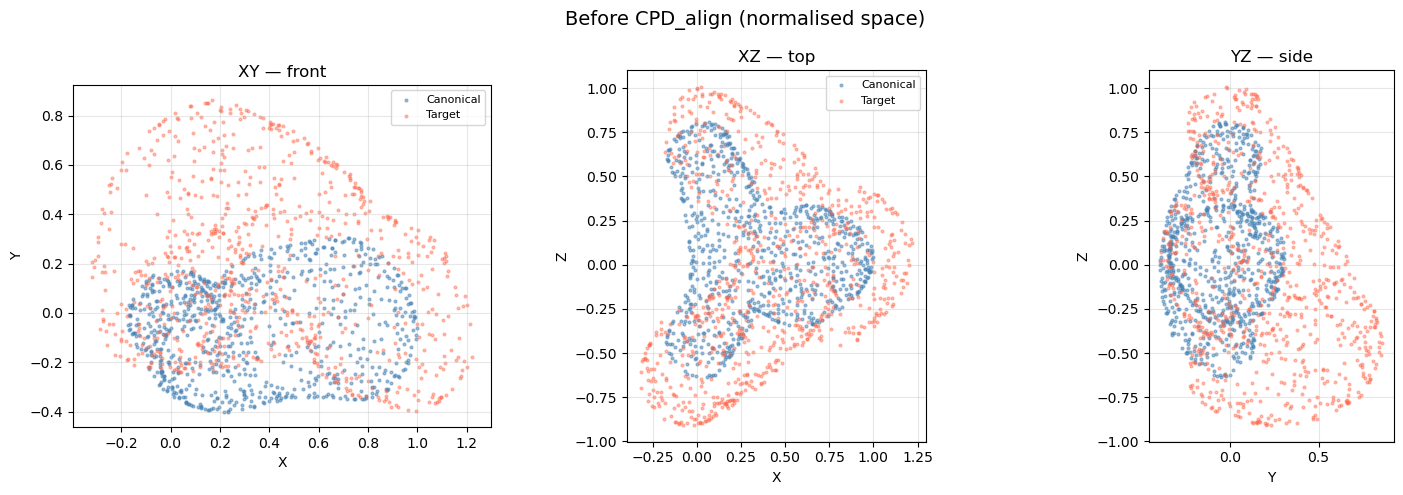

Before CPD: 0.110452


In [6]:
# ── Visualise BEFORE CPD alignment ───────────────────────────────────────
import matplotlib.pyplot as plt

def _plot_alignment_3views(Va, Vb, title, la="Canonical", lb="Target", n=800):
    rng = np.random.default_rng(0)
    ia  = rng.choice(len(Va), min(n, len(Va)), replace=False)
    ib  = rng.choice(len(Vb), min(n, len(Vb)), replace=False)
    views = [("XY — front", 0, 1, "X", "Y"),
             ("XZ — top",   0, 2, "X", "Z"),
             ("YZ — side",  1, 2, "Y", "Z")]
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(title, fontsize=14)
    for ax, (vname, xi, yi, xl, yl) in zip(axes, views):
        ax.scatter(Va[ia, xi], Va[ia, yi], s=4, alpha=0.5, c="steelblue", label=la)
        ax.scatter(Vb[ib, xi], Vb[ib, yi], s=4, alpha=0.4, c="tomato",    label=lb)
        ax.set_xlabel(xl); ax.set_ylabel(yl)
        ax.set_title(vname)
        ax.set_aspect("equal")
        ax.grid(True, alpha=0.3)
        if xi == 0:
            ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

_plot_alignment_3views(V_n, V_tgt_n, "Before CPD_align (normalised space)")
print(f'Before CPD: {_chamfer_p3d(V_n.astype(np.float32), F, V_tgt_n.astype(np.float32), F_target):.6f}')


In [5]:
# ── Chamfer distance helper ───────────────────────────────────────────────────
from pytorch3d.structures import Meshes
from pytorch3d.loss import chamfer_distance
from pytorch3d.ops import sample_points_from_meshes

def _chamfer_p3d(Va, Fa, Vb, Fb, n=5000):
    ma = Meshes(verts=[torch.tensor(Va)], faces=[torch.tensor(Fa)])
    mb = Meshes(verts=[torch.tensor(Vb)], faces=[torch.tensor(Fb)])
    xa = sample_points_from_meshes(ma, num_samples=n)
    xb = sample_points_from_meshes(mb, num_samples=n)
    return chamfer_distance(xa, xb)[0].item()

In [ ]:
# # ── STEP 4b: CPD rigid refinement ───────────────────────────────────────────
# # CPD: V_n @ R.T + t ≈ V_tgt_n  (canonical moves toward target)
# # Inverse: bring target into canonical frame  V_tgt_can = (V_tgt_n - t) @ R

# # _, R_cpd, t_cpd = cpd_align(V_n, V_tgt_n)
# # V_tgt_can = ((V_tgt_n.astype(np.float64) - t_cpd) @ R_cpd).astype(np.float32)

# _, R_cpd, t_cpd = cpd_align(V_n, V_tgt_n)
# # Only apply rotation — keep bif at origin for both
# V_tgt_can = (V_tgt_n @ R_cpd).astype(np.float32)

# print(f'CPD: det(R)={np.linalg.det(R_cpd):.6f},  |t|={np.linalg.norm(t_cpd):.6f}')
# print(f'After CPD: {_chamfer_p3d(V_n.astype(np.float32), F, V_tgt_can, F_target):.6f}')

# # ring_pairs: apply same rotation to target ring positions
# if ring_pairs is not None:
#     ring_pairs = [
#         (ci, (tp.astype(np.float64) @ R_cpd).astype(np.float32))
#         for ci, tp in ring_pairs
#     ]

# # centroid_pairs: apply same rotation to target centroids (shape (3,) each)
# if centroid_pairs is not None:
#     centroid_pairs = [
#         (ci, (tgt_c.astype(np.float64) @ R_cpd).astype(np.float32))
#         for ci, tgt_c in centroid_pairs
#     ]

# # # Transform ring target positions into canonical frame (with translation)
# # if ring_pairs is not None:
# #     ring_pairs = [
# #         (ci, ((tp.astype(np.float64) - t_cpd) @ R_cpd).astype(np.float32))
# #         for ci, tp in ring_pairs
# #     ]


In [ ]:
# # ── Visualise CPD alignment ──────────────────────────────────────────────
# _plot_alignment_3views(V_n.astype(np.float32), V_tgt_can, "After CPD")


In [7]:
# ── Trimesh 3D overlay: CPD-aligned canonical vs target ──────────────────────
import trimesh

mesh_can = trimesh.Trimesh(vertices=V_n.astype(np.float32), faces=F, process=False)
mesh_tgt_viz = trimesh.Trimesh(vertices=V_tgt_n, faces=F_target, process=False)

mesh_can.visual.face_colors     = [255, 0, 0, 120]   # red  = canonical (aligned)
mesh_tgt_viz.visual.face_colors = [0, 0, 255, 120]   # blue = target

trimesh.Scene([mesh_can, mesh_tgt_viz]).show()


In [33]:
# ── STEP 4d: Set GHD initialiser ────────────────────────────────────────────────────────
V_init_np = V_n.copy().astype(np.float32)   # canonical stays fixed in its own frame
print('V_init shape:', V_init_np.shape, '  dtype:', V_init_np.dtype)


V_init shape: (2582, 3)   dtype: float32


In [34]:
# ── STEP 5: Configure GHD fitting ───────────────────────────────────────────────────────
cfg = FitConfig(
    n_iter             = 15_000,
    lambda_chamfer     = 1.0,
    lambda_chamfer_n1  = 0.5,
    lambda_occupancy   = 1.0,
    lambda_laplacian   = 0.01, #1e-2
    lambda_consistency = 0.3,
    lambda_rigid_start = 3.0,
    lambda_rigid_end   = 0.001,
    rigid_decay_frac   = 0.7, #0.7
    lambda_ring_chamfer = 0.5,
    lambda_centroid    = 0.1,   # L2 centroid-to-centroid; increase to 0.3 if vessels still drift
    device             = 'cuda:2',
)
print(cfg)


FitConfig(n_iter=15000, lr=0.001, eta_min=1e-06, fit_R=True, fit_s=True, fit_T=True, num_samples=50000, n_dvs=10000, n_dvs_oversamp=150000, num_dvs_sample=12000, NP_ratio=1.0, lambda_chamfer=1.0, lambda_chamfer_n1=0.5, lambda_occupancy=1.0, lambda_laplacian=0.01, lambda_consistency=0.3, lambda_rigid_start=3.0, lambda_rigid_end=0.001, rigid_decay_frac=0.7, lambda_edge=0.1, lambda_ring_chamfer=0.5, lambda_centroid=0.1, log_every=200, save_every=1000, out_dir='ghd_debug_outputs', converge_threshold=0.95, device='cuda:2')


In [35]:
# ── STEP 6: Run GHD fitting ──────────────────────────────────────────────────
V0_np = V_init_np.copy()   # kept for post-fit displacement visualisation

result = ghd_fit(
    V_init         = V_init_np,
    F              = F,
    V_tgt          = V_tgt_n.astype(np.float32),
    F_tgt          = F_target,
    U              = U.astype(np.float32),
    cfg            = cfg,
    ring_pairs     = ring_pairs,
    centroid_pairs = centroid_pairs,
)

V_final = result.verts   # (N, 3) fitted mesh in normalised space


Preparing DVS samples...


  trimesh.contains: 0.4s
  DVS: 43003 interior pts, 106997 exterior pts
Baseline Chamfer: 0.177605
Starting GHD fitting loop...
Iter     0 | Chamfer: 0.177950 | N1: 0.5096 | Occ: 0.6195 | Lap: 2.36e-03 | Cons: 5.38e-03 | Edge: 0.0000 | Rigid: 0.0000 (w=3.000) | RingCh: 0.3733 | CentC: 0.0740 | Total: 1.247941 | lr: 1.00e-03 | 9.1 it/s
Iter   200 | Chamfer: 0.066673 | N1: 0.3538 | Occ: 0.3490 | Lap: 2.93e-03 | Cons: 5.38e-03 | Edge: 0.0002 | Rigid: 0.0105 (w=2.943) | RingCh: 0.3078 | CentC: 0.0577 | Total: 0.784838 | lr: 1.00e-03 | 17.4 it/s
Iter   400 | Chamfer: 0.040656 | N1: 0.3140 | Occ: 0.2346 | Lap: 3.25e-03 | Cons: 5.36e-03 | Edge: 0.0004 | Rigid: 0.0223 (w=2.886) | RingCh: 0.3031 | CentC: 0.0573 | Total: 0.655520 | lr: 9.98e-04 | 17.4 it/s
Iter   600 | Chamfer: 0.031785 | N1: 0.2765 | Occ: 0.1876 | Lap: 3.32e-03 | Cons: 5.33e-03 | Edge: 0.0005 | Rigid: 0.0363 (w=2.829) | RingCh: 0.2908 | CentC: 0.0562 | Total: 0.612926 | lr: 9.96e-04 | 17.4 it/s
Iter   800 | Chamfer: 0.029251 | 

In [36]:
# ── STEP 7b: Fit summary ───────────────────────────────────────────────────────────────────
print(f'Chamfer (best)  : {result.chamfer_best:.6f}  @ iter {result.best_iter}')
print(f'Chamfer (final) : {result.chamfer_final:.6f}')
print(f'Dice score      : {result.dice:.4f}')
print(f'GAR             : {result.gar:.4f}')
print(f'Converged       : {result.converged}')

m = trimesh.Trimesh(vertices=V_final, faces=F, process=False)
print('watertight          :', m.is_watertight)
print('winding consistent  :', m.is_winding_consistent)
print('Euler number        :', m.euler_number)


Chamfer (best)  : 0.000229  @ iter 14486
Chamfer (final) : 0.000232
Dice score      : 0.9976
GAR             : 0.7434
Converged       : True
watertight          : True
winding consistent  : True
Euler number        : 2


In [ ]:
# Change this in the notebook after the fit:
print(f"scale (log_s_ghd): {result.loss_history['scale'][-1]:.4f}")
print(f"target/canonical size ratio (input data): {np.max(np.linalg.norm(V_target, axis=1)) / s_can:.4f}")


In [37]:
# ── STEP 8: Export fitted mesh ────────────────────────────────────────────────
from pathlib import Path

# V_final is in normalised target space (CPD already moved canonical → target orientation).
#
# OPTION A — canonical normalised space (for shape analysis / VAE training)
result_mesh = trimesh.Trimesh(vertices=V_final, faces=F, process=False)

# OPTION B — target world space (for CFD, in mm)
# V_final is already in target orientation — just un-normalise, do NOT undo CPD.
# V_world     = V_final.astype(np.float64) * s_can   # neck at origin, units mm
# result_mesh = trimesh.Trimesh(vertices=V_world, faces=F, process=False)

out_path = REPO_ROOT / 'fitting_results/C0014_cut2/ghd_fitted.obj'
out_path.parent.mkdir(parents=True, exist_ok=True)
result_mesh.export(str(out_path))
print(f'Saved: {out_path}')

Saved: /media/yaplab2/HDD Storage/almaha/Aneu_GHD/fitting_results/C0014_cut2/ghd_fitted.obj


In [ ]:
import trimesh

mesh_fit = trimesh.Trimesh(vertices=V_final, faces=F, process=False)
mesh_tgt = trimesh.Trimesh(vertices=V_tgt_n, faces=F_target, process=False)

mesh_fit.visual.face_colors = [255, 0, 0, 120]   # red  = fitted
mesh_tgt.visual.face_colors = [0, 0, 255, 120]   # blue = target

trimesh.Scene([mesh_fit, mesh_tgt]).show()


In [ ]:
import numpy as np
import trimesh
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# assume V0, V_final, F, and optionally V_tgt_n, F_target already exist
Vf_np = np.asarray(V_final)
F_np  = np.asarray(F)

# displacement stats
disp = np.linalg.norm(Vf_np - V0_np, axis=1)
print(f"max displacement: {disp.max():.6f}")
print(f"mean displacement: {disp.mean():.6f}")
print(f"std displacement: {disp.std():.6f}")

# blue -> red colors per vertex
norm = mcolors.Normalize(vmin=disp.min(), vmax=disp.max())
rgba = (cm.get_cmap('coolwarm')(norm(disp)) * 255).astype(np.uint8)

mesh_fit = trimesh.Trimesh(vertices=Vf_np, faces=F_np, process=False)
mesh_fit.visual.vertex_colors = rgba

# optional: overlay target in transparent blue
scene_meshes = [mesh_fit]
if 'V_tgt_n' in globals() and 'F_target' in globals():
    mesh_tgt = trimesh.Trimesh(vertices=V_tgt_n, faces=F_target, process=False)
    mesh_tgt.visual.face_colors = [0, 0, 255, 80]
    scene_meshes.append(mesh_tgt)

scene = trimesh.Scene(scene_meshes)
scene.show()   # interactive rotate/zoom/pan


In [ ]:
print("Neck at origin check:", V.mean(axis=0).round(3))   # won't be 0 — centroid ≠ neck
# Better: load neck_pt from the saved landmarks
import numpy as np
lm = np.load("/media/yaplab2/HDD Storage/almaha/GHD2/Checkpoints/Alignment/p044_BBMdFxESDBMcEwcVBhMBExQC/landmarks.npz", allow_pickle=True)
print("Landmark keys:", list(lm.keys()))
print("neck in aligned space:", lm['neck'].round(3))   # should be [0, 0, 0]
print("neck_pt_world:", lm['neck_pt_world'].round(3))  # pre-alignment world coords


In [ ]:
lm_tgt = np.load("/media/yaplab2/HDD Storage/almaha/Aneu_GHD/Checkpoints/Alignment/Mm988eVmYt_aneurysm1/landmarks.npz", allow_pickle=True)
print("neck in aligned space:", np.array(lm_tgt['neck']).round(3))   # should be [0,0,0]


In [12]:
import trimesh
import numpy as np
from pytorch3d.structures import Meshes
from pytorch3d.loss import chamfer_distance
from pytorch3d.ops import sample_points_from_meshes
import torch

fitted = trimesh.load("/media/yaplab2/HDD Storage/almaha/Aneu_GHD/fitting_results/NHS/Mm988eVmYt_aneurysm1/world/ghd_fitted.obj", process=False)
target = trimesh.load("/media/yaplab2/HDD Storage/almaha/Aneu_GHD/Checkpoints/Alignment/Mm988eVmYt_aneurysm1/final_aligned.obj", process=False)

# ── 1. Size check ──────────────────────────────────────────────────────────
print(f"Fitted max_r : {np.linalg.norm(fitted.vertices, axis=1).max():.3f} mm")
print(f"Target max_r : {np.linalg.norm(target.vertices, axis=1).max():.3f} mm")

# # ── 2. Chamfer distance (mm) ───────────────────────────────────────────────
# def chamfer_mm(va, fa, vb, fb, n=10000):
#     ma = Meshes(verts=[torch.tensor(va, dtype=torch.float32)], faces=[torch.tensor(fa)])
#     mb = Meshes(verts=[torch.tensor(vb, dtype=torch.float32)], faces=[torch.tensor(fb)])
#     xa = sample_points_from_meshes(ma, n)
#     xb = sample_points_from_meshes(mb, n)
#     return chamfer_distance(xa, xb)[0].item() ** 0.5   # sqrt → units of mm

# cd = chamfer_mm(fitted.vertices, fitted.faces, target.vertices, target.faces)
# print(f"Chamfer dist : {cd:.4f} mm")

# # ── 3. Hausdorff distance (mm) ────────────────────────────────────────────
# from scipy.spatial import cKDTree
# d_f2t = cKDTree(target.vertices).query(fitted.vertices)[0]
# d_t2f = cKDTree(fitted.vertices).query(target.vertices)[0]
# print(f"Hausdorff    : {max(d_f2t.max(), d_t2f.max()):.3f} mm")
# print(f"Mean surf dist: {np.concatenate([d_f2t, d_t2f]).mean():.4f} mm")

# ── 4. Volume check (watertight only) ─────────────────────────────────────
if fitted.is_watertight and target.is_watertight:
    print(f"Fitted volume: {fitted.volume:.2f} mm³")
    print(f"Target volume: {target.volume:.2f} mm³")
    print(f"Volume ratio : {fitted.volume / target.volume:.4f}  ← should be ~1.0")


Fitted max_r : 7.086 mm
Target max_r : 7.105 mm
Fitted volume: 186.69 mm³
Target volume: 183.58 mm³
Volume ratio : 1.0169  ← should be ~1.0


In [11]:
# normalized space Chamfer → mm equivalent
print(f"Normalized Chamfer in mm: {0.000686**0.5 * s_can:.4f} mm")


Normalized Chamfer in mm: 0.1408 mm
